## 1.Loading Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path

project_root = Path.cwd().parent

fund_master = pd.read_csv(project_root / "data/raw/01_fund_master.csv")
nav_history = pd.read_csv(project_root / "data/raw/02_nav_history.csv")
transactions = pd.read_csv(project_root / "data/raw/08_investor_transactions.csv")
holdings = pd.read_csv(project_root / "data/raw/09_portfolio_holdings.csv")

fund_master: (40, 15)
nav_history: (46000, 3)
transactions: (32778, 13)
holdings: (322, 8)


## 2. Historical VaR (95%) and CVaR

In [7]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
).copy()

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [8]:
returns = nav_history["daily_return"].dropna()

print("Min Return :", returns.min())
print("Max Return :", returns.max())
print("Mean Return:", returns.mean())
print("Std Return :", returns.std())

Min Return : -0.058102013949189124
Max Return : 0.06471309359097144
Mean Return: 0.0006310517590547711
Std Return : 0.010290414788248919


In [10]:
var_cvar_list = []

for fund_code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)

    cvar = returns[returns <= var_95].mean()

    var_cvar_list.append(
        {
            "amfi_code": fund_code,
            "VaR_95": var_95,
            "CVaR": cvar
        }
    )

var_cvar_df = pd.DataFrame(var_cvar_list)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
var_cvar_df = var_cvar_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR,scheme_name,fund_house
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [12]:
var_cvar_df.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR,scheme_name,fund_house
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund


In [13]:
var_cvar_df.sort_values(
    "CVaR"
).head(10)

,amfi_code,VaR_95,CVaR,scheme_name,fund_house
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund


In [14]:
output_path = project_root / "reports" / "var_cvar_report.csv"

var_cvar_df.to_csv(
    output_path,
    index=False
)

print(output_path)

/Users/sankalp/SRS (UNSYNCED)/Work/Bluestocks/bluestock_mf_capstone/reports/var_cvar_report.csv


## 3. Rolling 90-Day Sharpe Ratio

In [17]:
key_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    120841,  # Kotak Bluechip
    119092   # Axis Bluechip
]

rolling_sharpe_df = nav_history[
    nav_history["amfi_code"].isin(key_funds)
].copy()

rolling_sharpe_df.shape

(5750, 4)

In [18]:
rolling_sharpe_df["rolling_sharpe"] = (
    rolling_sharpe_df
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
17250,118632,2022-01-03,42.8339,NaN,NaN
17251,118632,2022-01-04,42.8033,-0.000714,NaN
17252,118632,2022-01-05,43.0564,0.005913,NaN
17253,118632,2022-01-06,43.2088,0.003540,NaN
17254,118632,2022-01-07,42.9585,-0.005793,NaN


In [19]:
rolling_sharpe_df = rolling_sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe,scheme_name
0,118632,2022-01-03,42.8339,NaN,NaN,Nippon India Large Cap Fund - Regular - Growth
1,118632,2022-01-04,42.8033,-0.000714,NaN,Nippon India Large Cap Fund - Regular - Growth
2,118632,2022-01-05,43.0564,0.005913,NaN,Nippon India Large Cap Fund - Regular - Growth
3,118632,2022-01-06,43.2088,0.003540,NaN,Nippon India Large Cap Fund - Regular - Growth
4,118632,2022-01-07,42.9585,-0.005793,NaN,Nippon India Large Cap Fund - Regular - Growth


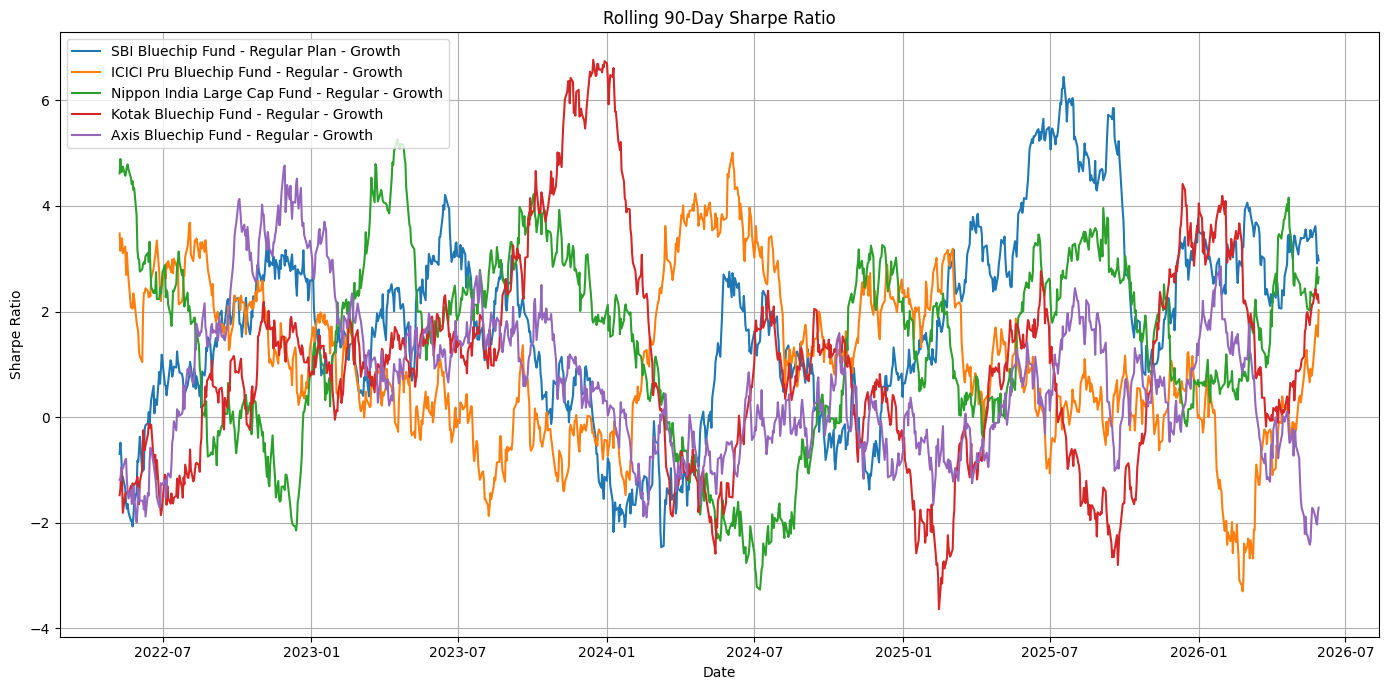

/Users/sankalp/SRS (UNSYNCED)/Work/Bluestocks/bluestock_mf_capstone/reports/rolling_sharpe_chart.png


In [21]:
output_path = project_root / "reports" / "rolling_sharpe_chart.png"

plt.figure(figsize=(14, 7))

for fund in key_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=temp["scheme_name"].iloc[0]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(output_path)

## 4. Investor Cohort Analysis

In [23]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print(
    transactions["transaction_date"].min()
)

print(
    transactions["transaction_date"].max()
)

2024-01-01 00:00:00
2025-05-30 00:00:00


In [24]:
transactions["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [26]:
first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [27]:
transactions = transactions.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [28]:
investments = transactions[
    transactions["transaction_type"]
    .isin(["SIP", "Lumpsum"])
].copy()

cohort_summary = (
    investments
    .groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        investor_count=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_invested,investor_count
0,2024,81879.117557,2258062304,4770
1,2025,81513.454936,18992635,173


In [29]:
cohort_fund = (
    investments
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transactions")
)

cohort_fund = cohort_fund.sort_values(
    ["cohort_year", "transactions"],
    ascending=[True, False]
)

top_funds = (
    cohort_fund
    .groupby("cohort_year")
    .head(1)
)

top_funds

,cohort_year,amfi_code,transactions
33,2024,125498,752
62,2025,119599,11


In [30]:
top_funds = top_funds.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_funds

,cohort_year,amfi_code,transactions,scheme_name
0,2024,125498,752,HDFC Mid-Cap Opportunities Fund - Direct - Growth
1,2025,119599,11,SBI Small Cap Fund - Direct Plan - Growth


## 5. SIP Continuity Analysis

In [31]:
sip_txns = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_txns.shape

(19716, 14)

In [32]:
sip_counts = (
    sip_txns
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

len(eligible_investors)

1362

In [33]:
sip_txns = sip_txns[
    sip_txns["investor_id"]
    .isin(eligible_investors)
].copy()

sip_txns.shape

(9679, 14)

In [34]:
sip_txns = sip_txns.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024


In [35]:
sip_txns["gap_days"] = (
    sip_txns
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txns.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0
31897,INV000004,2025-05-17,119599,SIP,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,49.0
9329,INV000008,2024-05-27,101206,SIP,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,NaN
11113,INV000008,2024-06-23,102887,SIP,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified,2024,27.0
21549,INV000008,2024-12-05,100025,SIP,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified,2024,165.0
24389,INV000008,2025-01-18,119552,SIP,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,44.0


In [36]:
sip_continuity = (
    sip_txns
    .groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days", "mean"),
        sip_count=("transaction_date", "count")
    )
    .reset_index()
)

sip_continuity.head()

,investor_id,avg_gap_days,sip_count
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [37]:
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At-Risk",
    "Healthy"
)

sip_continuity.head()

,investor_id,avg_gap_days,sip_count,status
0,INV000004,85.400000,6,At-Risk
1,INV000008,70.400000,6,At-Risk
2,INV000010,64.800000,6,At-Risk
3,INV000011,40.166667,7,At-Risk
4,INV000012,57.000000,8,At-Risk


In [38]:
sip_continuity["status"].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

## 6. Simple Fund Recommender

In [44]:
scorecard = pd.read_csv(
    project_root / "reports" / "fund_scorecard.csv"
)

recommender_df = scorecard.merge(
    fund_master[
        ["amfi_code", "risk_category"]
    ],
    on="amfi_code",
    how="left"
)

recommender_df.head()

,amfi_code,scheme_name,CAGR_3Y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,fund_score,risk_category
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.29,-0.2015,0.0375,-24.73,1.55,0.150,0.150,0.050,0.2250,0.175,14.38,Moderate
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.92,-0.5671,0.0428,-4.31,0.56,0.175,0.050,0.075,0.9750,0.925,31.88,Low
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,1.0937,0.2720,-16.22,1.38,0.925,0.850,0.875,0.6000,0.525,80.75,High
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,1.0272,0.2140,-11.29,1.60,0.800,0.800,0.725,0.1125,0.800,68.19,Moderate
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.15,0.1627,0.1090,-35.45,1.53,0.050,0.325,0.350,0.3125,0.075,22.06,Very High


In [45]:
recommender_df["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Low                 6
Very High           6
Moderately High     4
Name: count, dtype: int64

## 7. Sector HHI Concentration

In [49]:
sector_hhi = (
    holdings
    .groupby("amfi_code")
    .apply(
        lambda x: (x["weight_pct"] ** 2).sum()
    )
    .reset_index(name="HHI")
)

sector_hhi.head()

,amfi_code,HHI
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


In [50]:
sector_hhi = sector_hhi.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

sector_hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,1395.3386,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,1475.9226,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,1293.3173,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [51]:
sector_hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name,category
11,119092,2064.4767,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,1747.5096,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,1682.9820,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,1679.2973,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,1575.7036,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,1537.9360,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,1524.1398,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,1496.8035,Kotak Bluechip Fund - Regular - Growth,Equity


In [52]:
sector_hhi.sort_values(
    "HHI",
    ascending=True
).head(10)

,amfi_code,HHI,scheme_name,category
17,119598,1073.4895,SBI Small Cap Fund - Regular Plan - Growth,Equity
16,119552,1080.1069,SBI Bluechip Fund - Direct Plan - Growth,Equity
9,118634,1083.5772,Nippon India Small Cap Fund - Regular - Growth,Equity
20,120504,1086.7415,ICICI Pru Bluechip Fund - Direct - Growth,Equity
14,119095,1096.0535,Axis Small Cap Fund - Regular - Growth,Equity
5,102886,1146.9284,UTI Mid Cap Fund - Regular - Growth,Equity
33,149324,1186.7710,DSP Small Cap Fund - Regular - Growth,Equity
15,119551,1187.1552,SBI Bluechip Fund - Regular Plan - Growth,Equity
8,118633,1214.6086,Nippon India Large Cap Fund - Direct - Growth,Equity
24,120842,1274.3881,Kotak Emerging Equity Fund - Regular - Growth,Equity


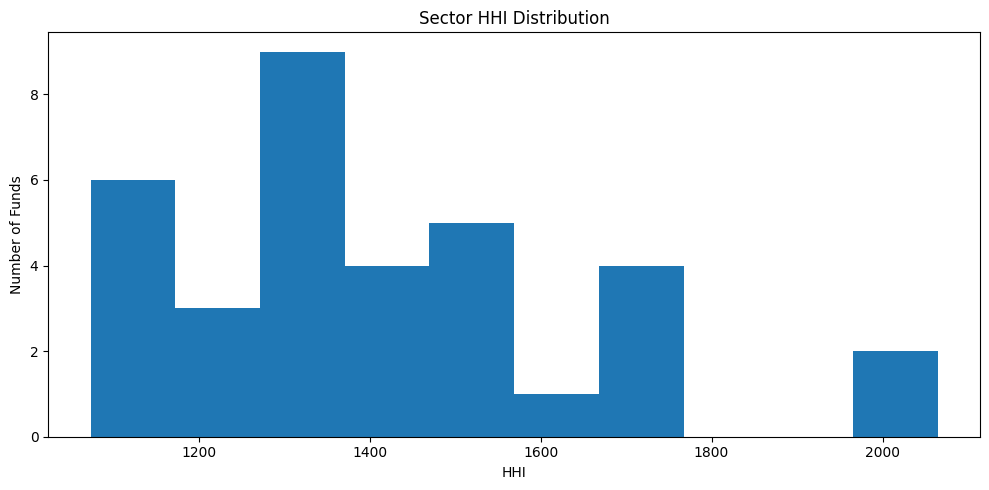

In [53]:
plt.figure(figsize=(10, 5))

plt.hist(
    sector_hhi["HHI"],
    bins=10
)

plt.title("Sector HHI Distribution")
plt.xlabel("HHI")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.show()

## 8. Advanced Insights

### Insight 1 — Downside Risk Analysis

Historical VaR and CVaR analysis shows that small-cap funds exhibit the highest downside risk. SBI Small Cap Fund, Axis Small Cap Fund, ABSL Small Cap Fund, and DSP Small Cap Fund recorded the most negative VaR and CVaR values, indicating greater vulnerability during adverse market conditions. Investors seeking stability may prefer large-cap or debt-oriented funds with lower downside exposure.

### Insight 2 — Rolling Sharpe Stability

The Rolling 90-Day Sharpe Ratio analysis revealed that large-cap funds experienced significant fluctuations in risk-adjusted performance over time. While all funds underwent periods of weaker performance, funds with consistently positive Sharpe values demonstrated stronger risk-adjusted returns across different market environments.

### Insight 3 — Investor Cohort Behaviour

The 2024 investor cohort dominates the dataset with over 4,700 unique investors and more than ₹2.25 billion invested. HDFC Mid-Cap Opportunities Fund emerged as the most preferred scheme within this cohort, indicating strong investor interest in mid-cap growth opportunities.

### Insight 4 — SIP Continuity Risk

Among investors with at least six SIP transactions, approximately 98% were classified as At-Risk based on an average gap exceeding 35 days between SIP contributions. This suggests weak contribution consistency and highlights the need for investor engagement and retention initiatives.

### Insight 5 — Portfolio Concentration

Sector HHI analysis identified notable differences in portfolio diversification across equity funds. Axis Bluechip Fund and ABSL Small Cap Fund exhibited the highest concentration levels, while SBI Bluechip Direct and Nippon India Small Cap showed relatively lower concentration scores, indicating broader sector diversification.